# End-to-End Demo

Tutorial notebooks (`01`-`07`) build every component from scratch in-place. This notebook is the *showcase*: it imports the finished package from `src/transformer/` and runs the full pipeline end-to-end.

1. Load the Shakespeare corpus and build a char vocabulary
2. Instantiate the decoder-only transformer
3. Sample text from the untrained model (random baseline)
4. Train for 3000 steps with Adam
5. Plot the loss curve
6. Report deterministic validation perplexity
7. Sample with temperature, top-k, and top-p
8. Verify the KV-cache fast-decode path
9. Visualize the learned attention heads

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

from transformer.data import load_corpus, split_data
from transformer.evaluate import perplexity
from transformer.generate import generate
from transformer.model import Transformer
from transformer.train import TrainConfig, train
from transformer.utils import set_seed
from transformer.visualize import plot_all_heads

rng = set_seed(42)

## 1. Corpus and vocabulary

In [2]:
text, vocab, data = load_corpus('../data/input.txt')

print(f'Corpus length: {len(text):,} chars')
print(f'Vocab size:    {vocab.size}')
print(f'Characters:    {repr("".join(vocab.chars))}')

Corpus length: 10,160 chars
Vocab size:    58
Characters:    "\n !',-.:;?ABCDEFGHIJLMNOPRSTUVWYabcdefghijklmnopqrstuvwxyz"


## 2. Model

In [3]:
model = Transformer(
    vocab_size=vocab.size,
    d_model=64,
    n_heads=4,
    d_ff=256,
    n_layers=3,
    max_seq_len=32,
    dropout=0.1,
    tie_weights=True,
    rng=rng,
)
print(f'Parameters: {model.count_params():,}')

Parameters: 153,082


## 3. Sample before training

In [4]:
# Own rng so this untrained sample does not advance the training stream.
print(generate(model, vocab, start='First', max_new_tokens=120, temperature=1.0,
               rng=np.random.default_rng(0)))

FirsteF!
oucjYvo
q j?qYHP :gfdNzyhfhN:jWIUsvLbIcJOsDd,pmEr!J;SnD!OB-bHgBwM-evRxVPdzwSlVWmPjiv.jvx
ryx;ysoUDnvFYRv!jd j
lWv'p'


## 4. Train

In [5]:
train_data, val_data = split_data(data, val_fraction=0.1)
config = TrainConfig(
    n_steps=int(os.environ.get('DEMO_STEPS', 3000)),
    batch_size=32, seq_len=32, lr=1e-3, weight_decay=0.01,
    warmup_steps=100, min_lr_ratio=0.1,
    log_every=500, eval_every=500, eval_batches=20,
)
history = train(model, train_data, config, val_data=val_data, rng=rng)
losses = history.train_loss

step   500/3000 | loss 3.1943 | 42.5 steps/s
step   500/3000 | val_loss 2.8681


step  1000/3000 | loss 2.5918 | 41.1 steps/s


step  1000/3000 | val_loss 2.4126


step  1500/3000 | loss 2.2869 | 38.1 steps/s


step  1500/3000 | val_loss 2.2749


step  2000/3000 | loss 2.1300 | 37.7 steps/s
step  2000/3000 | val_loss 2.2422


step  2500/3000 | loss 2.0498 | 37.6 steps/s
step  2500/3000 | val_loss 2.2389


step  3000/3000 | loss 2.0125 | 37.3 steps/s
step  3000/3000 | val_loss 2.1786


## 5. Loss curve

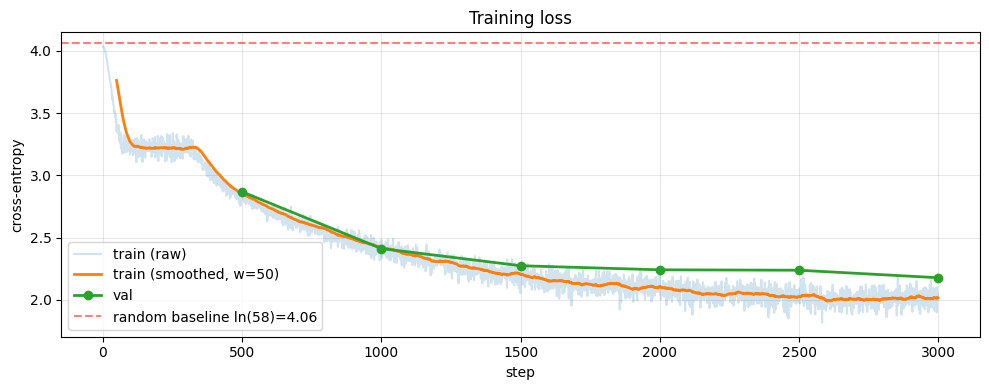

In [6]:
window = min(50, len(losses))
smoothed = np.convolve(losses, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.2, label='train (raw)')
plt.plot(range(window - 1, len(losses)), smoothed, linewidth=2, label=f'train (smoothed, w={window})')
if history.val_loss:
    val_steps, val_vals = zip(*history.val_loss)
    plt.plot(val_steps, val_vals, 'o-', linewidth=2, color='C2', label='val')
plt.axhline(np.log(vocab.size), color='red', linestyle='--', alpha=0.5, label=f'random baseline ln({vocab.size})={np.log(vocab.size):.2f}')
plt.xlabel('step')
plt.ylabel('cross-entropy')
plt.title('Training loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Validation perplexity

Deterministic perplexity over the full validation set (contiguous non-overlapping windows, token-weighted). Lower is better; a uniform model over the 58-char vocabulary would score 58.

In [7]:
val_ppl = perplexity(model, val_data, batch_size=32, seq_len=32)
print(f'Validation perplexity: {val_ppl:.2f}  (uniform baseline = {vocab.size})')

Validation perplexity: 8.93  (uniform baseline = 58)


## 7. Sampling strategies

Same trained model, three decoding rules. Temperature reshapes the full distribution; top-k keeps the k most likely characters; top-p (nucleus) keeps the smallest set whose cumulative probability reaches p.

In [8]:
prompt = 'First Citizen'
runs = [
    ('temperature 0.8', dict(temperature=0.8)),
    ('top-k = 10', dict(temperature=1.0, top_k=10)),
    ('top-p = 0.9', dict(temperature=1.0, top_p=0.9)),
]
for label, kwargs in runs:
    print(f'--- {label} ---')
    print(generate(model, vocab, start=prompt, max_new_tokens=200, rng=rng, **kwargs))
    print()

--- temperature 0.8 ---
First Citizen:
That youu the hatsh so fars, id and lins unf that wrod
Of the' not how nope and focw bestly what buge o' e distrint the selas, beoft, ris greint of the tay fus as ar andy, thirs buve heave yourind e

--- top-k = 10 ---


First Citizen: ou the ore thit thive mucer ins,
You t ille asend bend and these anselored on mis the mod deve cacont to do they: devemy, whe ben isth sis sened, bars,
Wherouster that susirer yauringins;
The''s buk

--- top-p = 0.9 ---
First Citizen:
Wo to the catly you
hank he it derl deve, hind
Wherit your ar hid mink you crives and und hik mams nom nour theirs;
And it corlls brorst arinshe loow pitize and ar ans spely ar brit, you if that
Tha



## 8. KV-cache fast decode

The incremental decode path caches each layer's K and V, so step t does O(t) work instead of re-running the whole prefix. It must produce text identical to the plain path. The speedup grows with context length; see `experiments/bench_kv_cache.py` for the measurement.

In [9]:
short = 'First '
plain = generate(model, vocab, start=short, max_new_tokens=25, temperature=0.8,
                 rng=set_seed(7), use_cache=False)
cached = generate(model, vocab, start=short, max_new_tokens=25, temperature=0.8,
                  rng=set_seed(7), use_cache=True)
print('cache matches plain decode:', plain == cached)
print(cached)

cache matches plain decode: True
First Citizen:
Secooret: you a 


## 9. Learned attention heads

Feed a short prompt through the trained model and inspect every head in block 0. Each head learns a different mix of local and positional attention.

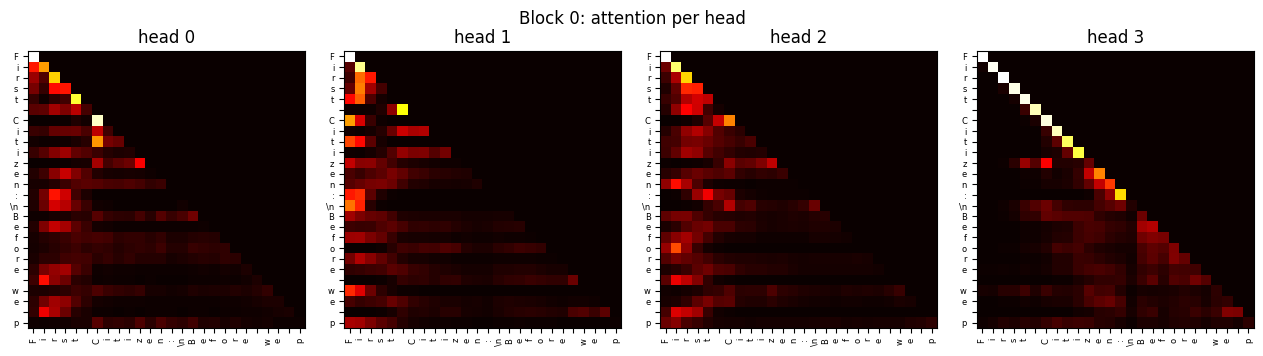

In [10]:
plot_all_heads(model, vocab, prompt='First Citizen:\nBefore we p', layer=0)
plt.show()